In [2]:
import fastf1  # https://docs.fastf1.dev/getting_started/basics.html

In [14]:
# loading a session
session = fastf1.get_session(2025, 24, "R")

In [15]:
session.event

RoundNumber                                                         24
Country                                           United Arab Emirates
Location                                                    Yas Island
OfficialEventName    FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...
EventDate                                          2025-12-07 00:00:00
EventName                                         Abu Dhabi Grand Prix
EventFormat                                               conventional
Session1                                                    Practice 1
Session1Date                                 2025-12-05 13:30:00+04:00
Session1DateUtc                                    2025-12-05 09:30:00
Session2                                                    Practice 2
Session2Date                                 2025-12-05 17:00:00+04:00
Session2DateUtc                                    2025-12-05 13:00:00
Session3                                                    Practice 3
Sessio

In [16]:
session.load(laps=True, weather=True)  # IMPORTANT: loads all available data for the session from various APIs

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

In [17]:
w = session.laps
w.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [22]:
len(w[["PitOutTime", "PitInTime"]].isna() == False)

1156

In [54]:
wtime = type(w["LapTime"])
wtime

pandas.core.series.Series

In [44]:
session.laps["Compound"].unique()

array(['SOFT', 'MEDIUM'], dtype=object)

In [42]:
schedule = fastf1.get_event_schedule(2026)
schedule["EventName"]

0           Pre-Season Testing
1           Pre-Season Testing
2        Australian Grand Prix
3           Chinese Grand Prix
4          Japanese Grand Prix
5           Bahrain Grand Prix
6     Saudi Arabian Grand Prix
7             Miami Grand Prix
8          Canadian Grand Prix
9            Monaco Grand Prix
10        Barcelona Grand Prix
11         Austrian Grand Prix
12          British Grand Prix
13          Belgian Grand Prix
14        Hungarian Grand Prix
15            Dutch Grand Prix
16          Italian Grand Prix
17          Spanish Grand Prix
18       Azerbaijan Grand Prix
19        Singapore Grand Prix
20    United States Grand Prix
21      Mexico City Grand Prix
22        São Paulo Grand Prix
23        Las Vegas Grand Prix
24            Qatar Grand Prix
25        Abu Dhabi Grand Prix
Name: EventName, dtype: object

In [41]:
import pandas as pd

# data pulled from https://motorsporttickets.com/blog/how-many-laps-does-each-formula-1-race-have/ and Formula1 website
# I have all tracks used from 2024-2026 seasons
data = {
    "track": ["Australian Grand Prix", "Chinese Grand Prix", "Japanese Grand Prix", "Bahrain Grand Prix", "Saudi Arabian Grand Prix", "Miami Grand Prix", "Canadian Grand Prix", "Monaco Grand Prix", "Barcelona Grand Prix", "Austrian Grand Prix", "British Grand Prix", "Belgian Grand Prix", "Hungarian Grand Prix", "Dutch Grand Prix", "Italian Grand Prix", "Spanish Grand Prix", "Azerbaijan Grand Prix", "Singapore Grand Prix", "United States Grand Prix", "Mexico City Grand Prix", "São Paulo Grand Prix", "Las Vegas Grand Prix", "Qatar Grand Prix", "Abu Dhabi Grand Prix", "Emilia Romagna Grand Prix", "Spain Grand Prix"],
    "circuit": ["Melbourne Grand Prix Circuit", "Shanghai International Circuit", "Suzuka", "Bahrain International Circuit", "Jeddah Street Circuit", "Hard Rock Stadium Circuit", "Circuit Gilles Villeneuve", "Circuit de Monaco", "Circuit de Barcelona-Catalunya", "Red Bull Ring", "Silverstone Circuit", "Circuit de Spa-Francorchamps", "Hangaroring", "Zandvoort", "Autodromo Nazionale di Monza", "Madring Circuit", "Baku City Circuit", "Marina Bay Street Circuit", "Circuit of the Americas", "Autodromo Hermanos Rodriguez", "Autodromo Jose Carlos Pace", "Las Vegas Street Circuit", "Lusail Circuit", "Yas Marina Circuit", "Autodromo Enzo e Dino Ferrari", "Circuit de Barcelona-Catalunya"],
    "circuit_length (km)": [5.303, 5.451, 5.807, 5.412, 6.175, 5.41, 4.361, 3.337, 4.655, 4.318, 5.891, 7.004, 4.381, 4.259, 5.793, 5.474, 6.003, 5.063, 5.513, 4.304, 4.309, 6.201, 5.419, 5.554, 4.909, 4.657],
    "race_distance (km)": [307.574, 305.066, 307.471, 308.238, 308.750, 308.37, 305.270, 260.286, 307.104, 306.452, 306.198, 308.052, 306.630, 306.648, 306.720, 312.018, 306.049, 308.706, 308.405, 305.354, 305.879, 310.05, 308.826, 305.355, 309.049, 307.236],
    "laps": [58, 56, 53, 57, 50, 57, 70, 78, 66, 71, 52, 44, 70, 72, 53, 57, 51, 61, 56, 71, 71, 50, 57, 55, 63, 66] 
}

track_df = pd.DataFrame(data)
track_df

,track,circuit,circuit_length (km),race_distance (km),laps
0,Australian Grand Prix,Melbourne Grand Prix Circuit,5.303,307.574,58
1,Chinese Grand Prix,Shanghai International Circuit,5.451,305.066,56
2,Japanese Grand Prix,Suzuka,5.807,307.471,53
3,Bahrain Grand Prix,Bahrain International Circuit,5.412,308.238,57
4,Saudi Arabian Grand Prix,Jeddah Street Circuit,6.175,308.750,50
5,Miami Grand Prix,Hard Rock Stadium Circuit,5.410,308.370,57
6,Canadian Grand Prix,Circuit Gilles Villeneuve,4.361,305.270,70
7,Monaco Grand Prix,Circuit de Monaco,3.337,260.286,78
8,Barcelona Grand Prix,Circuit de Barcelona-Catalunya,4.655,307.104,66
9,Austrian Grand Prix,Red Bull Ring,4.318,306.452,71


In [9]:
# loading an event
event = fastf1.get_event(2025, 7)
event

RoundNumber                                                          7
Country                                                          Italy
Location                                                         Imola
OfficialEventName    FORMULA 1 AWS GRAN PREMIO DEL MADE IN ITALY E ...
EventDate                                          2025-05-18 00:00:00
EventName                                    Emilia Romagna Grand Prix
EventFormat                                               conventional
Session1                                                    Practice 1
Session1Date                                 2025-05-16 13:30:00+02:00
Session1DateUtc                                    2025-05-16 11:30:00
Session2                                                    Practice 2
Session2Date                                 2025-05-16 17:00:00+02:00
Session2DateUtc                                    2025-05-16 15:00:00
Session3                                                    Practice 3
Sessio

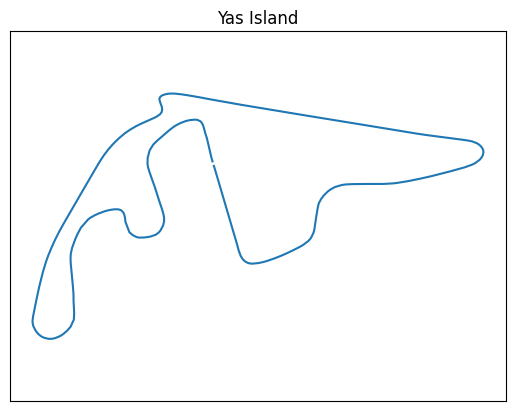

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# MAPPING THE SPECIFIC TRACK (https://docs.fastf1.dev/gen_modules/examples_gallery/plot_annotate_corners.html)

lap = session.laps.pick_fastest()  # IMPORTANT
pos = lap.get_pos_data()  # IMPORTANT 

circuit_info = session.get_circuit_info()  # IMPORTANT

def rotate(xy, *, angle):
    rot_mat = np.array([[np.cos(angle), np.sin(angle)],
                        [-np.sin(angle), np.cos(angle)]])
    return np.matmul(xy, rot_mat)

# Get an array of shape [n, 2] where n is the number of points and the second
# axis is x and y.
track = pos.loc[:, ('X', 'Y')].to_numpy()

# Convert the rotation angle from degrees to radian.
track_angle = circuit_info.rotation / 180 * np.pi

# Rotate and plot the track map.
rotated_track = rotate(track, angle=track_angle)
plt.plot(rotated_track[:, 0], rotated_track[:, 1])

offset_vector = [500, 0]  # offset length is chosen arbitrarily to 'look good'

# Iterate over all corners.
for _, corner in circuit_info.corners.iterrows():
    # Create a string from corner number and letter
    # txt = f"{corner['Number']}{corner['Letter']}"

    # Convert the angle from degrees to radian.
    offset_angle = corner['Angle'] / 180 * np.pi

    # Rotate the offset vector so that it points sideways from the track.
    offset_x, offset_y = rotate(offset_vector, angle=offset_angle)

    # Add the offset to the position of the corner
    text_x = corner['X'] + offset_x
    text_y = corner['Y'] + offset_y

    # Rotate the text position equivalently to the rest of the track map
    text_x, text_y = rotate([text_x, text_y], angle=track_angle)

    # Rotate the center of the corner equivalently to the rest of the track map
    track_x, track_y = rotate([corner['X'], corner['Y']], angle=track_angle)

    # # Draw a circle next to the track.
    # plt.scatter(text_x, text_y, color='grey', s=140)

    # # Draw a line from the track to this circle.
    # plt.plot([track_x, text_x], [track_y, text_y], color='grey')

    # Finally, print the corner number inside the circle.
    # plt.text(text_x, text_y, txt,
    #          va='center_baseline', ha='center', size='small', color='white')

plt.title(session.event['Location'])
plt.xticks([])
plt.yticks([])
plt.axis('equal')
plt.show()


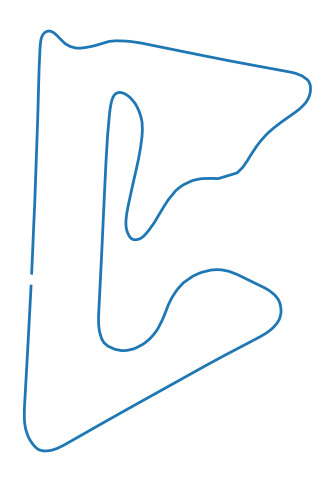

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/circuit_info.csv")

track_df = (
    df[
        (df["track"] == "Bahrain Grand Prix") &
        (df["type"] == "track")
    ]
    .sort_values("seq")
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(track_df["X"], track_df["Y"], linewidth=2)

ax.set_aspect("equal")
ax.axis("off")
plt.show()


In [ ]:
# get the mean and median of the lap time per track (distribution)
import seaborn as sns
import pandas as pd

laps = pd.read_csv("../data/lap_time_df.csv")

Index(['race_id', 'year', 'round', 'track', 'driver', 'team', 'race_lap',
       'stint', 'compound', 'tire_age', 'lap_time_sec', 'is_inlap',
       'is_outlap', 'circuit_length(km)'],
      dtype='object')

In [9]:
laps

,race_id,year,round,track,driver,team,race_lap,stint,compound,tire_age,lap_time_sec,is_inlap,is_outlap,circuit_length(km)
0,2024_01_Bahrain_Grand_Prix,2024,1,Bahrain Grand Prix,VER,Red Bull Racing,1.0,1.0,SOFT,4.0,97.284,False,False,5.412
1,2024_01_Bahrain_Grand_Prix,2024,1,Bahrain Grand Prix,LEC,Ferrari,1.0,1.0,SOFT,4.0,98.271,False,False,5.412
2,2024_01_Bahrain_Grand_Prix,2024,1,Bahrain Grand Prix,RUS,Mercedes,1.0,1.0,SOFT,4.0,99.228,False,False,5.412
3,2024_01_Bahrain_Grand_Prix,2024,1,Bahrain Grand Prix,NOR,McLaren,1.0,1.0,SOFT,4.0,102.168,False,False,5.412
4,2024_01_Bahrain_Grand_Prix,2024,1,Bahrain Grand Prix,HAM,Mercedes,1.0,1.0,SOFT,4.0,103.122,False,False,5.412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26376,2024_24_Abu_Dhabi_Grand_Prix,2024,24,Abu Dhabi Grand Prix,GAS,Alpine,58.0,2.0,HARD,44.0,90.865,False,False,5.554
26377,2024_24_Abu_Dhabi_Grand_Prix,2024,24,Abu Dhabi Grand Prix,HUL,Haas F1 Team,58.0,2.0,HARD,45.0,90.040,False,False,5.554
26378,2024_24_Abu_Dhabi_Grand_Prix,2024,24,Abu Dhabi Grand Prix,MAG,Haas F1 Team,57.0,5.0,SOFT,5.0,85.637,False,False,5.554
26379,2024_24_Abu_Dhabi_Grand_Prix,2024,24,Abu Dhabi Grand Prix,ALO,Aston Martin,58.0,3.0,HARD,22.0,88.621,False,False,5.554


In [ ]:
# create a distribution plot for lap time
TRACK = "Bahrain Grand Prix"

track_data = laps.loc[(laps["track"] == TRACK), ["driver", "lap_time_sec"]]
print("Analysis of Lap Times")
print(f"Minimum of {TRACK} (2024): {track_data['lap_time_sec'].min()}")  # 1.5 minutes
print(f"Maximum of {TRACK} (2024): {track_data['lap_time_sec'].max()}")  # 2.2 minutes
print(f"Mean of {TRACK} (2024): {track_data['lap_time_sec'].mean()}")
print(f"Median of {TRACK} (2024): {track_data['lap_time_sec'].median()}")
print(f"SD of {TRACK} (2024): {track_data['lap_time_sec'].std()}")

# the mean and median are close, so there is alot of variation

Analysis of Lap Times
Minimum of Bahrain Grand Prix (2024): 92.608
Maximum of Bahrain Grand Prix (2024): 132.438
Mean of Bahrain Grand Prix (2024): 98.00410825199644
Median of Bahrain Grand Prix (2024): 97.046
SD of Bahrain Grand Prix (2024): 4.500312960776377


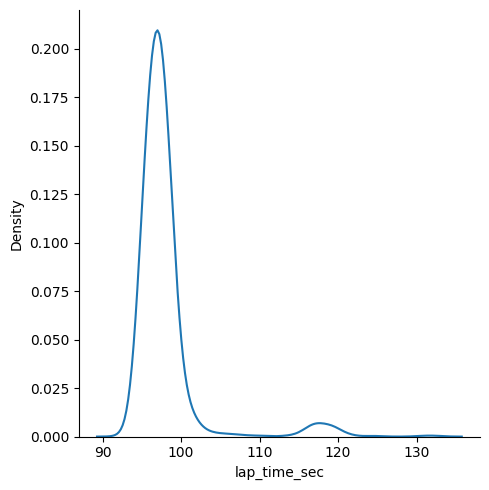

In [15]:
sns.displot(track_data, x="lap_time_sec", kind="kde")

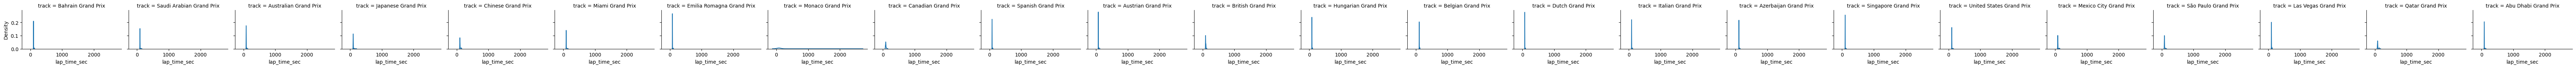

In [20]:
graph = sns.FacetGrid(laps, col="track", height=2, aspect=1.5)
graph.map(sns.kdeplot, "lap_time_sec")